In [65]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, matthews_corrcoef,roc_auc_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [66]:
datafile = "qsar-biodeg.csv"
df = pd.read_csv(datafile, header = 0)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V33,V34,V35,V36,V37,V38,V39,V40,V41,Class
0,3.919,2.6909,0,0,0,0,0,31.4,2,0,...,0,0,0,2.949,1.591,0,7.253,0,0,2
1,4.170,2.1144,0,0,0,0,0,30.8,1,1,...,0,0,0,3.315,1.967,0,7.257,0,0,2
2,3.932,3.2512,0,0,0,0,0,26.7,2,4,...,0,0,1,3.076,2.417,0,7.601,0,0,2
3,3.000,2.7098,0,0,0,0,0,20.0,0,2,...,0,0,1,3.046,5.000,0,6.690,0,0,2
4,4.236,3.3944,0,0,0,0,0,29.4,2,4,...,0,0,0,3.351,2.405,0,8.003,0,0,2


In [67]:
x = df.loc[:, df.columns != 'Class']
y = df.Class

In [68]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1) 

In [69]:
x_train.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41
count,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,...,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000
mean,4.796936,3.061358,0.705962,0.051491,1.031165,0.300813,1.631436,37.085772,1.432249,1.841463,...,0.140921,0.880759,1.336043,0.953930,3.899220,2.553535,0.691057,8.622102,0.054201,0.689702
std,0.532635,0.824610,1.466586,0.285429,2.538251,1.043959,2.165397,8.907636,1.885858,1.796443,...,0.704072,1.546874,2.426857,1.232989,0.941877,0.630999,1.089957,1.198452,0.333217,2.160438
min,2.000000,0.803900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.267000,1.500000,0.000000,4.917000,0.000000,0.000000
25%,4.499000,2.514825,0.000000,0.000000,0.000000,0.000000,0.000000,30.825000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,3.490750,2.100000,0.000000,8.001500,0.000000,0.000000
50%,4.836500,3.029050,0.000000,0.000000,0.000000,0.000000,1.000000,37.500000,1.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,3.724500,2.444000,0.000000,8.497000,0.000000,0.000000
75%,5.136250,3.439875,1.000000,0.000000,1.000000,0.000000,3.000000,42.900000,2.000000,3.000000,...,0.000000,1.750000,2.000000,2.000000,3.976750,2.898250,1.000000,9.052750,0.000000,0.000000
max,6.496000,7.918400,12.000000,3.000000,36.000000,13.000000,14.000000,60.000000,18.000000,12.000000,...,8.000000,12.000000,18.000000,6.000000,10.695000,5.750000,8.000000,14.700000,4.000000,27.000000


In [70]:
#Padroniza os dados de entrada
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)

In [71]:
pd.DataFrame(x_train).describe()

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
count,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,...,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000
mean,0.622094,0.317304,0.058830,0.017164,0.028643,0.023139,0.116531,0.618096,0.079569,0.153455,...,0.017615,0.073397,0.074225,0.158988,0.193666,0.247891,0.086382,0.378729,0.013550,0.025545
std,0.118469,0.115906,0.122215,0.095143,0.070507,0.080305,0.154671,0.148461,0.104770,0.149704,...,0.088009,0.128906,0.134825,0.205498,0.111756,0.148470,0.136245,0.122504,0.083304,0.080016
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.555827,0.240484,0.000000,0.000000,0.000000,0.000000,0.000000,0.513750,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.145201,0.141176,0.000000,0.315292,0.000000,0.000000
50%,0.630894,0.312763,0.000000,0.000000,0.000000,0.000000,0.071429,0.625000,0.055556,0.166667,...,0.000000,0.000000,0.000000,0.166667,0.172935,0.222118,0.000000,0.365941,0.000000,0.000000
75%,0.697565,0.370507,0.083333,0.000000,0.027778,0.000000,0.214286,0.715000,0.111111,0.250000,...,0.000000,0.145833,0.111111,0.333333,0.202865,0.329000,0.125000,0.422749,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [72]:
#Inicializa a classe RandomForest
rf = RandomForestClassifier()

#Elenca os hiperparâmetros a serem testados para a RandomForest
parameters = {
               'max_depth': [5, 10], 
               'n_estimators': [10, 100],
               'criterion': ['gini', 'entropy'],
                'max_features': ['sqrt', 10]
}

clf = GridSearchCV(rf, parameters, cv = 5, verbose = 2)

In [73]:
#Ajusta o melhor modelo (melhores hiper-parâmetros aos dados de treinamento)
clf.fit(x_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=10; total time=   0.1s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=10; total time=   0.0s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=10; total time=   0.0s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=10; total time=   0.0s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=10; total time=   0.0s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.2s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.4s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.4s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.5s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.5s
[CV]

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'], 'max_depth': [5, 10],
                         'max_features': ['sqrt', 10],
                         'n_estimators': [10, 100]},
             verbose=2)

In [74]:
print(clf.best_params_)

{'criterion': 'entropy', 'max_depth': 10, 'max_features': 10, 'n_estimators': 10}


In [75]:
2*2*2*2*5

80

In [76]:
x_test = scaler.transform(x_test)

In [77]:
#Aplica a predição no conjunto de teste
y_pred = clf.predict(x_test)

#Avalia a qualidade do modelo final
print(classification_report(y_test, y_pred)) 
accuracy_score(y_test, y_pred)

              precision    recall  f1-score   support

           1       0.86      0.95      0.90       206
           2       0.88      0.71      0.79       111

    accuracy                           0.86       317
   macro avg       0.87      0.83      0.84       317
weighted avg       0.87      0.86      0.86       317



0.8643533123028391

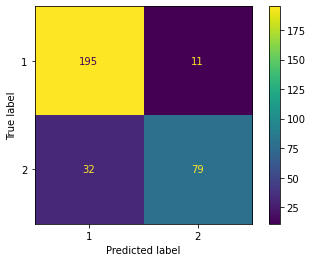

In [78]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(clf, x_test, y_test)

<AxesSubplot:>

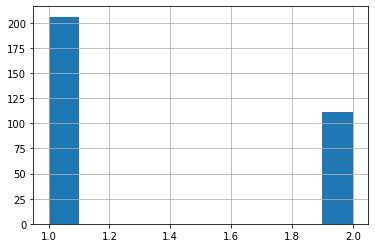

In [79]:
y_test.hist()

In [80]:
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy_score(y_test, y_pred)

0.8291568267296423

In [81]:
rf = RandomForestClassifier()
rf.set_params(**clf.best_params_)

rf.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=10, max_features=10,
                       n_estimators=10)

In [82]:
y_predb = rf.predict_proba(x_test)

In [83]:
y_predb

array([[0.9       , 0.1       ],
       [0.4       , 0.6       ],
       [0.9       , 0.1       ],
       [0.9       , 0.1       ],
       [0.3010989 , 0.6989011 ],
       [0.9       , 0.1       ],
       [1.        , 0.        ],
       [0.6       , 0.4       ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.1210989 , 0.8789011 ],
       [0.8       , 0.2       ],
       [1.        , 0.        ],
       [0.9       , 0.1       ],
       [1.        , 0.        ],
       [0.11776557, 0.88223443],
       [0.52      , 0.48      ],
       [0.3       , 0.7       ],
       [0.6025641 , 0.3974359 ],
       [0.48333333, 0.51666667],
       [0.96666667, 0.03333333],
       [0.1010989 , 0.8989011 ],
       [0.25010509, 0.74989491],
       [0.08677175, 0.91322825],
       [1.        , 0.        ],
       [0.1       , 0.9       ],
       [0.9       , 0.1       ],
       [0.11111111, 0.88888889],
       [0.01165501, 0.98834499],
       [0.

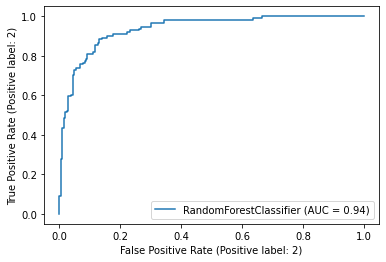

In [42]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(rf, x_test, y_test)

In [43]:
#E o impacto de cada atributo

In [84]:
rf.feature_importances_

array([0.05172573, 0.03282709, 0.0139448 , 0.00042178, 0.01867153,
       0.01438542, 0.02555975, 0.02667386, 0.02901641, 0.01308105,
       0.03383838, 0.03958644, 0.02016041, 0.03046399, 0.03341966,
       0.02282419, 0.02784838, 0.02927999, 0.0059759 , 0.        ,
       0.        , 0.09540394, 0.00273231, 0.        , 0.00042549,
       0.00104199, 0.05092574, 0.0158014 , 0.        , 0.01834799,
       0.01620466, 0.00365953, 0.02055503, 0.02560467, 0.01090599,
       0.10681766, 0.05462016, 0.01863215, 0.0774781 , 0.00809582,
       0.00304262])

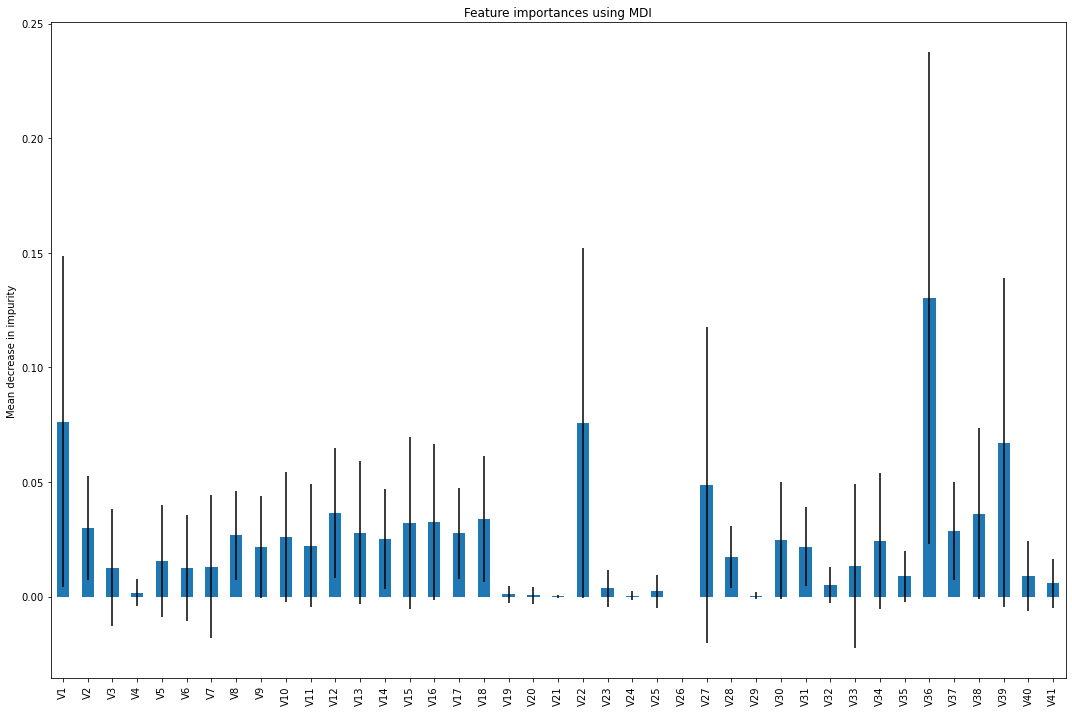

In [45]:
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

feature_names = [f"feature {i}" for i in range(x.shape[1])]
feature_names = x.columns
importances = rf.feature_importances_
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots(figsize = (15,10))

forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [48]:
import shap

In [62]:
def f(x):
    return rf.predict_proba(x)[:, 1]


med = pd.DataFrame(x_train).median().values.reshape((1, x_train.shape[1]))

explainer = shap.Explainer(f, med)
shap_values = explainer(pd.DataFrame(x_test).iloc[0:1000, :])

PermutationExplainer explainer: 318it [00:18,  8.13it/s]                        


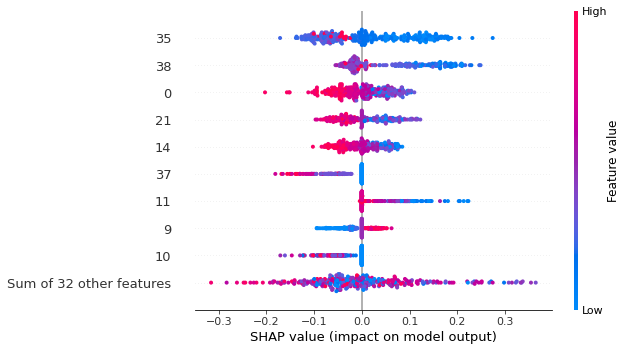

In [64]:
shap.plots.beeswarm(shap_values)